In [1]:
import os
import numpy as np
import pandas as pd
import torch

import mlflow
import mlflow.transformers
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc
)
from datasets import load_from_disk
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
import seaborn as sns

# Ensure results folder exists
os.makedirs("../models/distilbert_fake_news", exist_ok=True)

In [2]:
# ==============================
# Step 1. Load tokenized dataset
# ==============================
dataset_path = "../data/processed/tokenized"
dataset = load_from_disk(dataset_path)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 35918
    })
    validation: Dataset({
        features: ['label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 4490
    })
    test: Dataset({
        features: ['label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 4490
    })
})


In [8]:
# ==============================
# Step 2. Load tokenizer and model
# ==============================
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# LoRA config
lora_config = LoraConfig(
    r=8,               
    lora_alpha=16,    
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
)

# Wrap model with LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # ✅ confirms only LoRA params are trainable

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [9]:
# ==============================
# Step 3. Define metrics function
# ==============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

In [10]:
# ==============================
# Step 4. TrainingArguments
# ==============================
training_args = TrainingArguments(
    output_dir="../models/distilbert_fake_news",
    eval_strategy="steps",
    save_strategy="steps",      
    eval_steps=500,       
    save_steps=500,         
    learning_rate=3e-5,
    per_device_train_batch_size=4,      
    per_device_eval_batch_size=4,
    num_train_epochs=1,                 
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=200,                   
    report_to="none",
    dataloader_num_workers=0,           
    gradient_accumulation_steps=2,      
    fp16=False,                         
    disable_tqdm=False,
    log_level="error"
)


In [11]:
# ==============================
# Step 5. Trainer initialization
# ==============================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [12]:
# ==============================
# Step 6. MLflow setup
# ==============================
mlflow.set_experiment("FakeNews_DistilBERT")

with mlflow.start_run(run_name="distilbert_run"):
    mlflow.log_params({
        "model_name": model_name,
        "epochs": training_args.num_train_epochs,
        "lr": training_args.learning_rate,
        "batch_size": training_args.per_device_train_batch_size
    })

    trainer.train()

    eval_metrics = trainer.evaluate(dataset["test"])
    mlflow.log_metrics(eval_metrics)

    trainer.save_model("../models/distilbert_fake_news")
    mlflow.log_artifacts("../models/distilbert_fake_news")

    print("✅ Training complete. Metrics:", eval_metrics)

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.122400,0.030433,0.990423,0.990861,0.988969,0.992760
1000,0.008700,0.007387,0.998218,0.998298,0.997449,0.999148
1500,0.012300,0.006972,0.998664,0.998723,0.997874,0.999574
2000,0.002900,0.007726,0.998886,0.998936,0.997875,1.000000
2500,0.010100,0.007245,0.998886,0.998936,0.997875,1.000000
3000,0.015100,0.007165,0.998886,0.998936,0.997875,1.000000
3500,0.008300,0.007365,0.998886,0.998936,0.997875,1.000000
4000,0.003400,0.007083,0.998886,0.998936,0.997875,1.000000


d:\PROJECTS\Kaggle\fake-news-mlops\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
d:\PROJECTS\Kaggle\fake-news-mlops\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
d:\PROJECTS\Kaggle\fake-news-mlops\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
d:\PROJECTS\Kaggle\fake-news-mlops\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
d:\PROJECTS\Kaggle\fake-news-mlops\.

✅ Training complete. Metrics: {'eval_loss': 0.007543281652033329, 'eval_accuracy': 0.9979955456570155, 'eval_f1': 0.9980846988721005, 'eval_precision': 0.9974478945129732, 'eval_recall': 0.9987223168654173, 'eval_runtime': 736.1764, 'eval_samples_per_second': 6.099, 'eval_steps_per_second': 1.525, 'epoch': 1.0}


d:\PROJECTS\Kaggle\fake-news-mlops\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


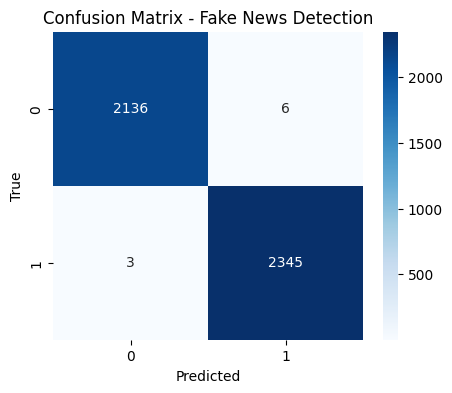

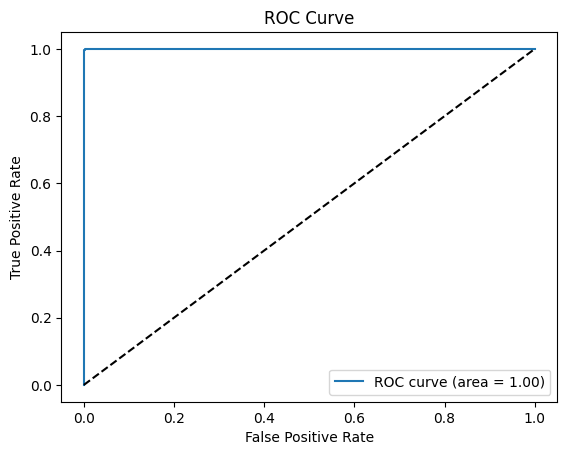

Test Accuracy: 0.9980


In [13]:
# ==============================
# Step 7. Evaluate & visualize
# ==============================
predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Compute confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fake News Detection")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(labels, predictions.predictions[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print(f"Test Accuracy: {accuracy_score(labels, preds):.4f}")